send finns: True
rec finns : True

Vald modell: Bohus
R_ref = 1.257525 Ω
X_ref = 6.555000 Ω
alpha = 0.00403 1/K
T_ref = 20.0 °C


C:\Users\lundi\AppData\Local\Temp\ipykernel_149988\720009794.py:104: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  D["Timestamp"] = pd.to_datetime(D["Timestamp"], errors="coerce")
C:\Users\lundi\AppData\Local\Temp\ipykernel_149988\720009794.py:104: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  D["Timestamp"] = pd.to_datetime(D["Timestamp"], errors="coerce")



Rådata:
send rows: 180000 rec rows: 180000
unika send timestamps: 15000
unika rec timestamps : 15000

Efter mappning:
send rows: 180000 rec rows: 180000
unika parametrar send: 12
unika parametrar rec : 12

Exakt join:
joined rows: 7669
start: 2025-12-11 15:25:02.469999
slut : 2025-12-11 15:27:32.450000
rows after filtering angles and dropna: 7669

Sampling:
fs = 50.00250012500625 Hz
smooth_window = 100 samples

=== Summary ===


,Phase,Model,R_ref_Ohm,X_ref_Ohm,U_mag_S_mean,U_mag_R_mean,I_mag_S_mean,I_mag_R_mean,U_ang_S_mean,U_ang_R_mean,I_ang_S_mean,I_ang_R_mean,I_ang_R_corr_mean,dU_mean_deg,dI_mean_deg,P_send_mean_W,P_rec_mean_W,R_mean_Ohm,R_std_Ohm,X_mean_Ohm,X_std_Ohm,T_mean_C,T_std_C
0,L1,Bohus,1.257525,6.555,80883.253383,80496.368343,191.352329,189.581683,164.599535,163.688732,162.736856,-18.258586,161.741414,0.898770,0.984417,1.546604e+07,1.524867e+07,1.784722,0.013036,6.716446,0.020233,124.028320,2.572391
1,L2,Bohus,1.257525,6.555,80873.212155,80555.784209,201.844450,199.935422,44.619834,43.732696,40.568157,-140.393725,39.606275,0.875989,0.954564,1.627749e+07,1.605842e+07,1.114641,0.011302,6.244582,0.018772,-8.194314,2.230181
2,L3,Bohus,1.257525,6.555,80929.100680,80685.289530,192.831843,190.632206,-75.398451,-76.308712,-81.443610,97.118344,-82.881656,0.898759,1.459783,1.551126e+07,1.527066e+07,0.509709,0.014160,6.713966,0.020318,-127.561448,2.794064



Sparat till: C:\Users\lundi\OneDrive\Skóli\Svíþjóð\Exjobb\Arbetet\Källor\phasor_dlr-main\phasor_dlr-main\data\bohus_v02.2_delta_U


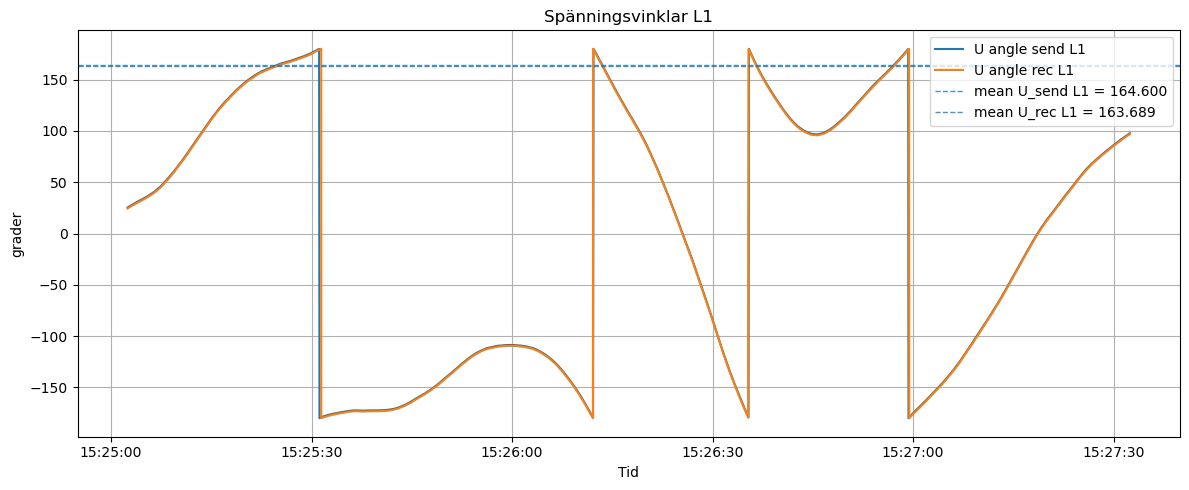

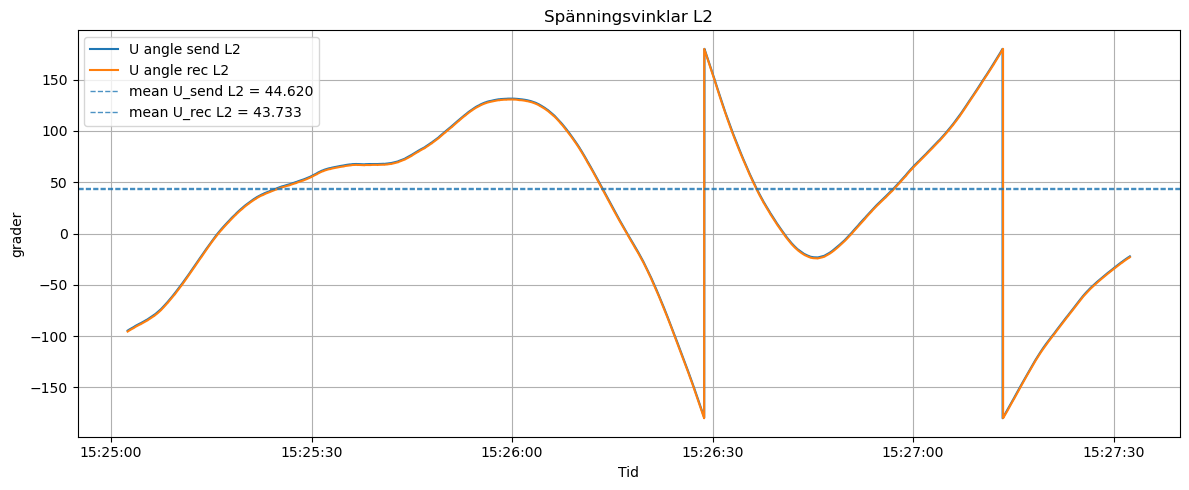

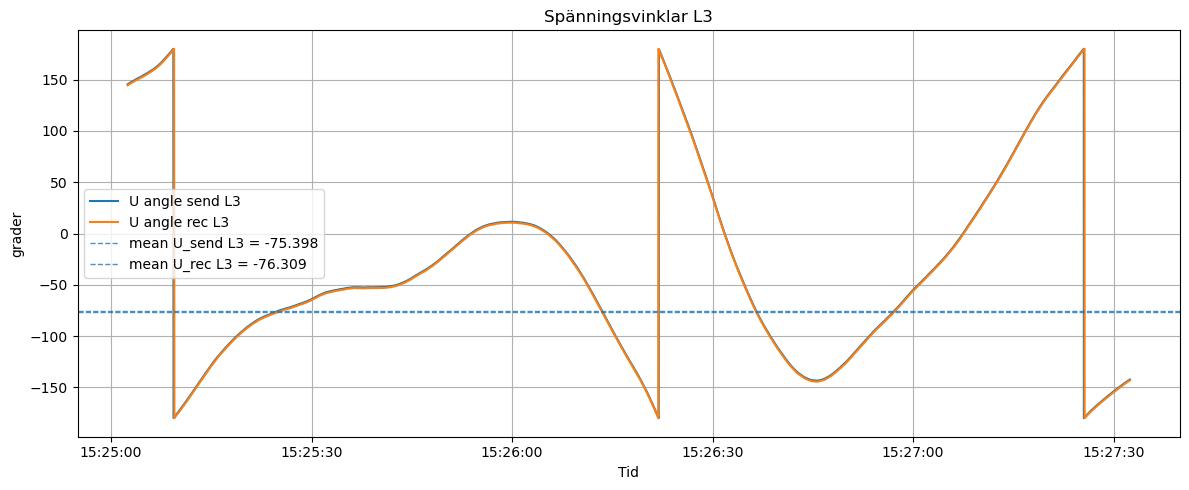

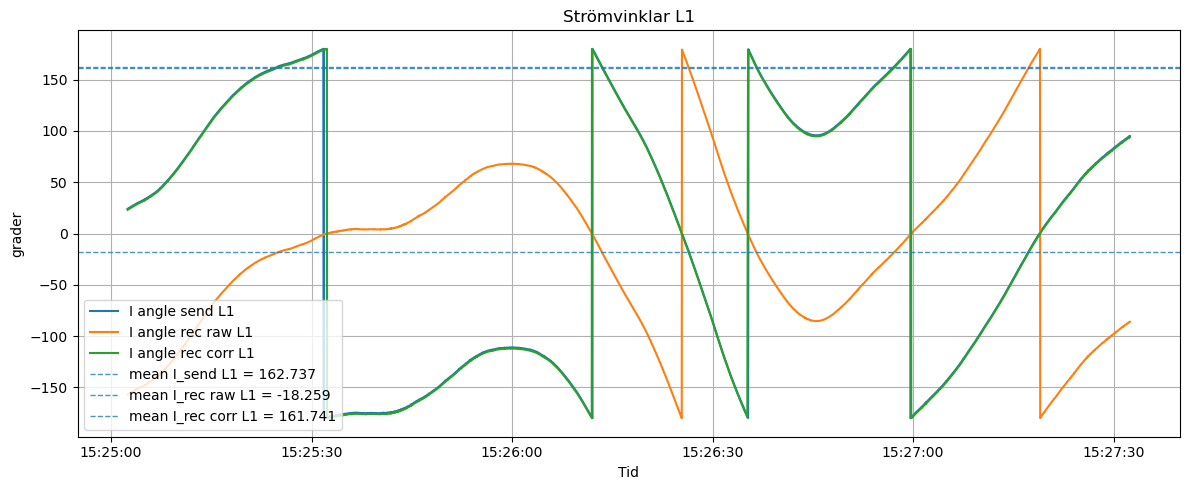

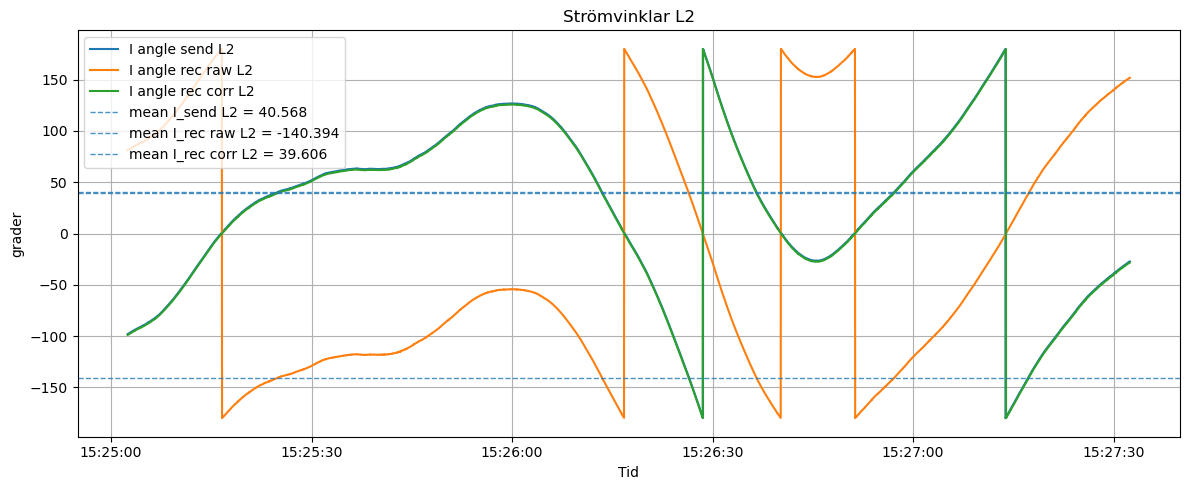

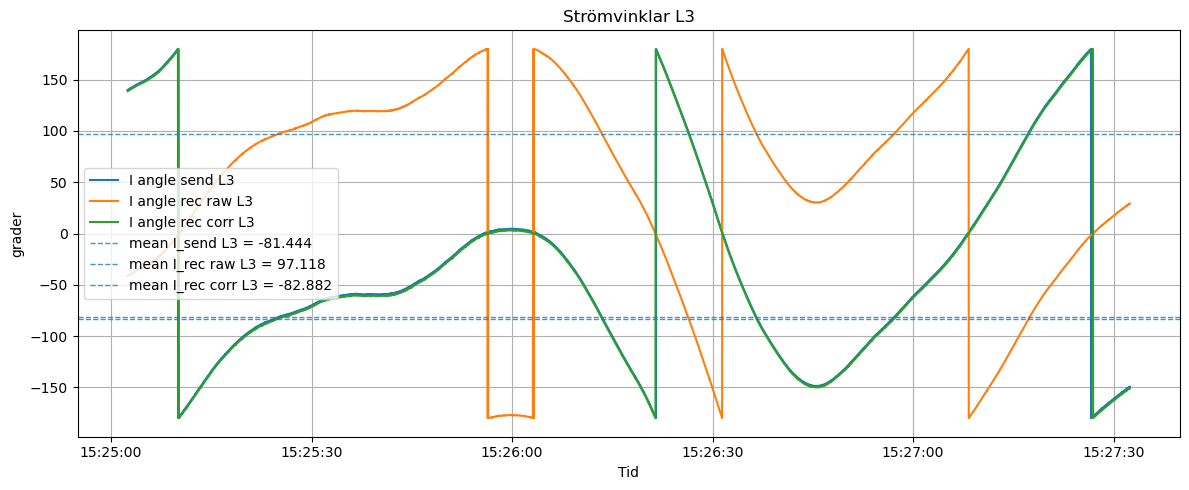

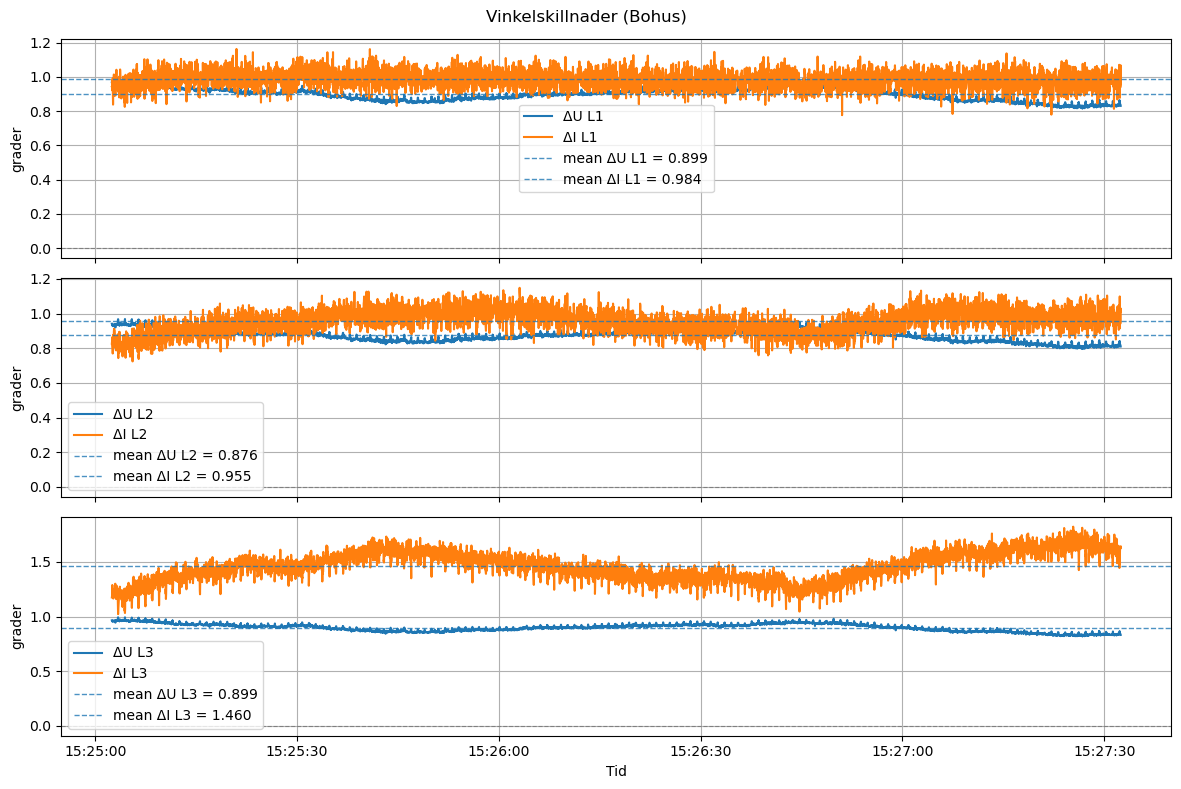

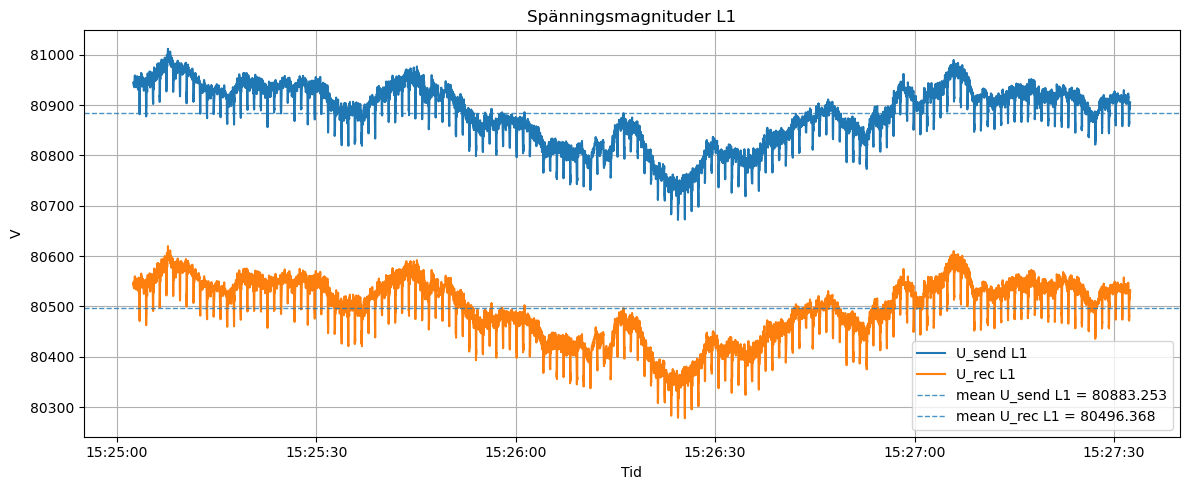

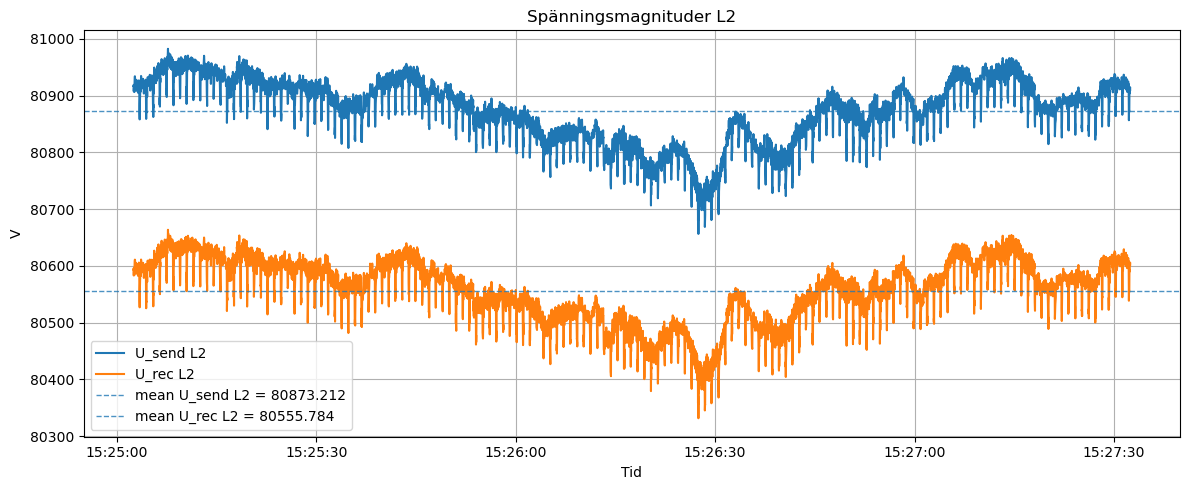

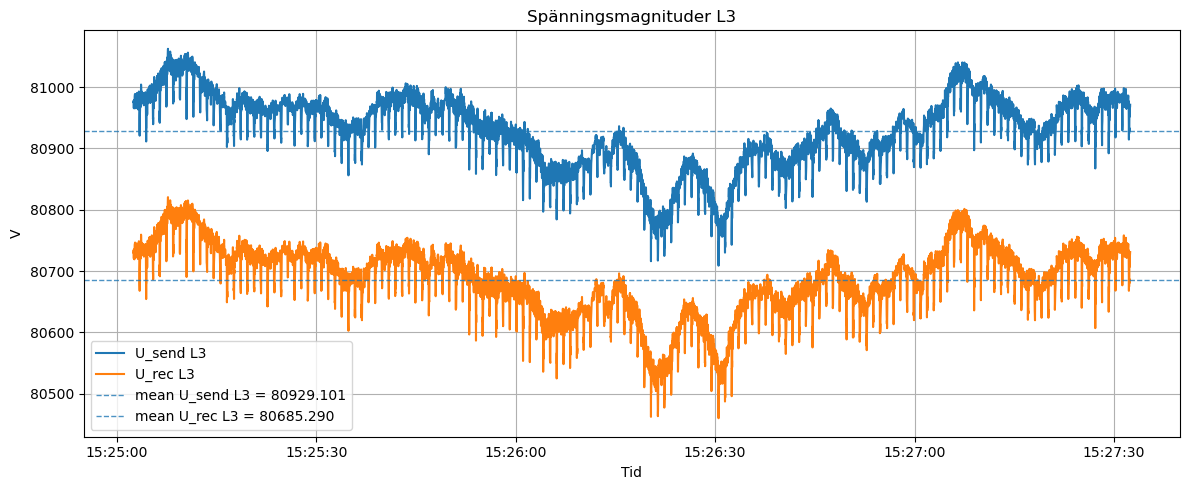

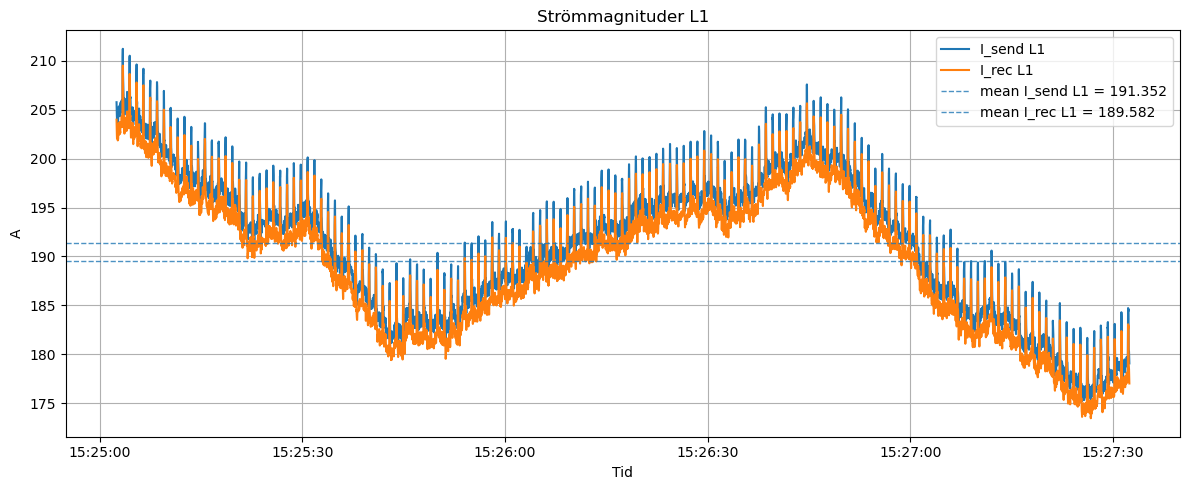

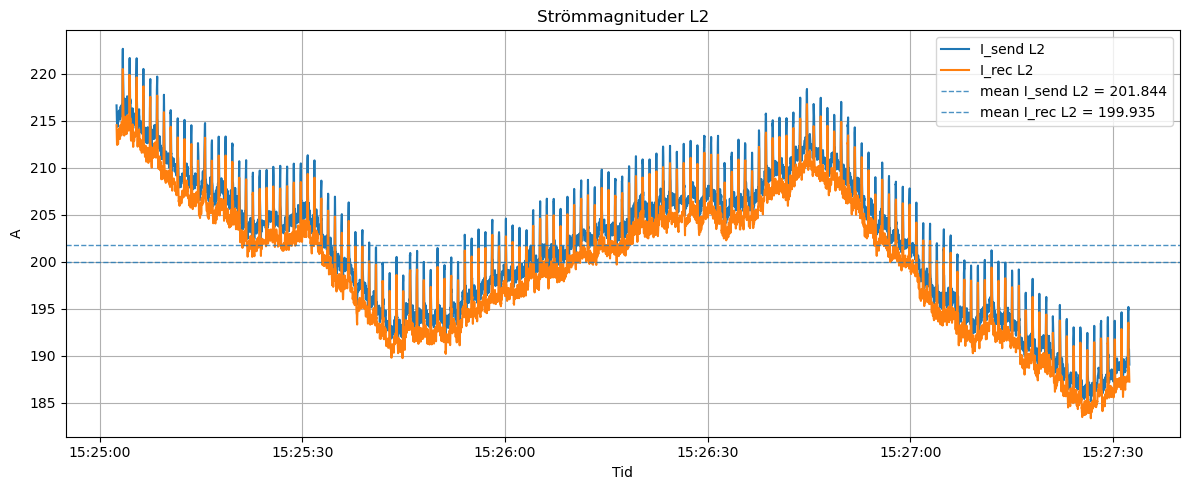

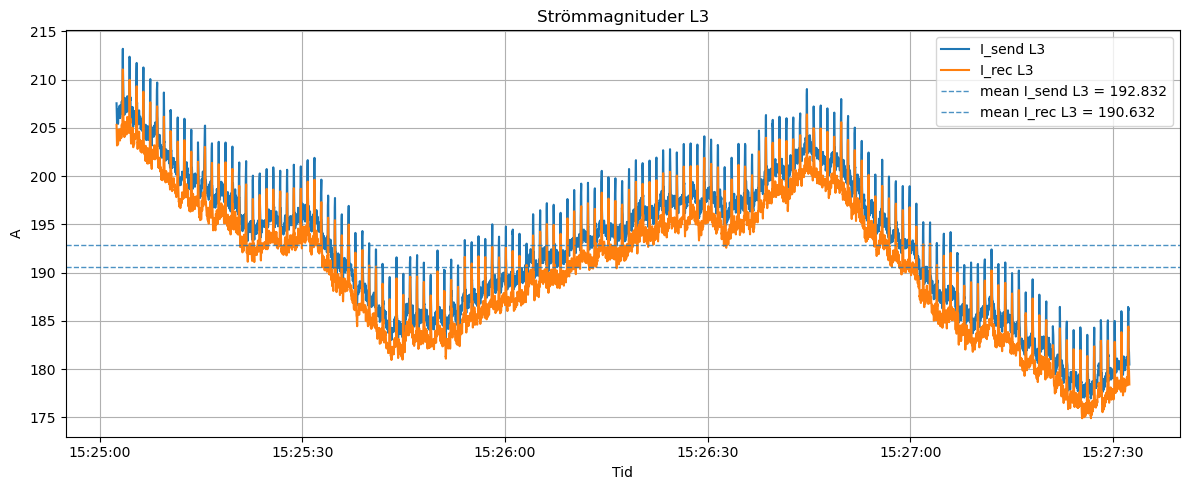

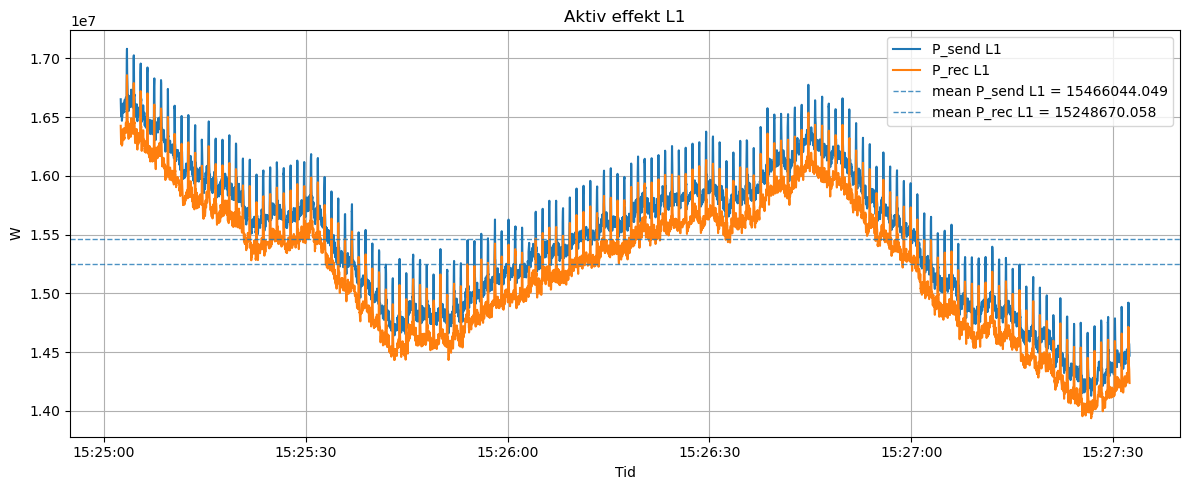

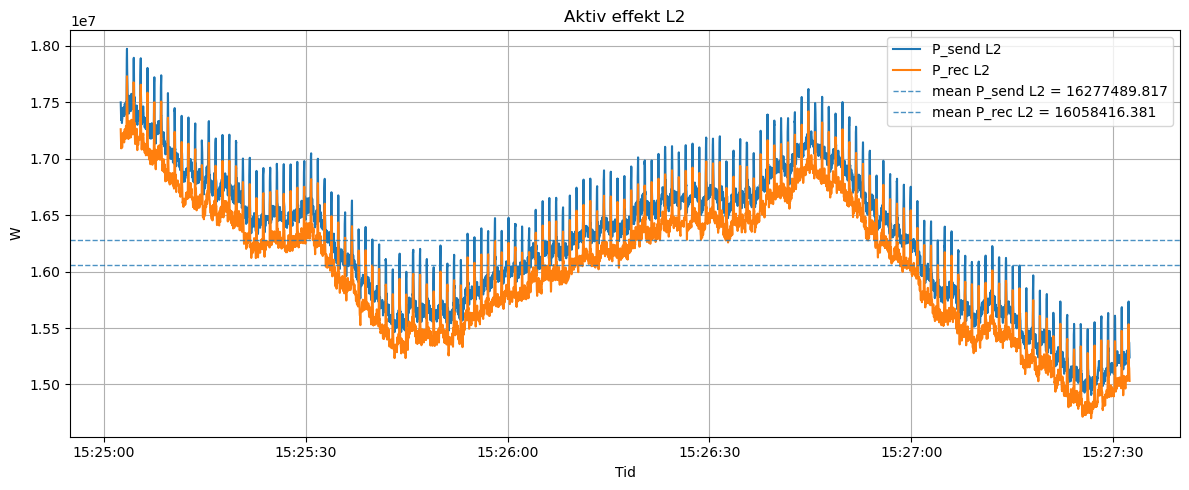

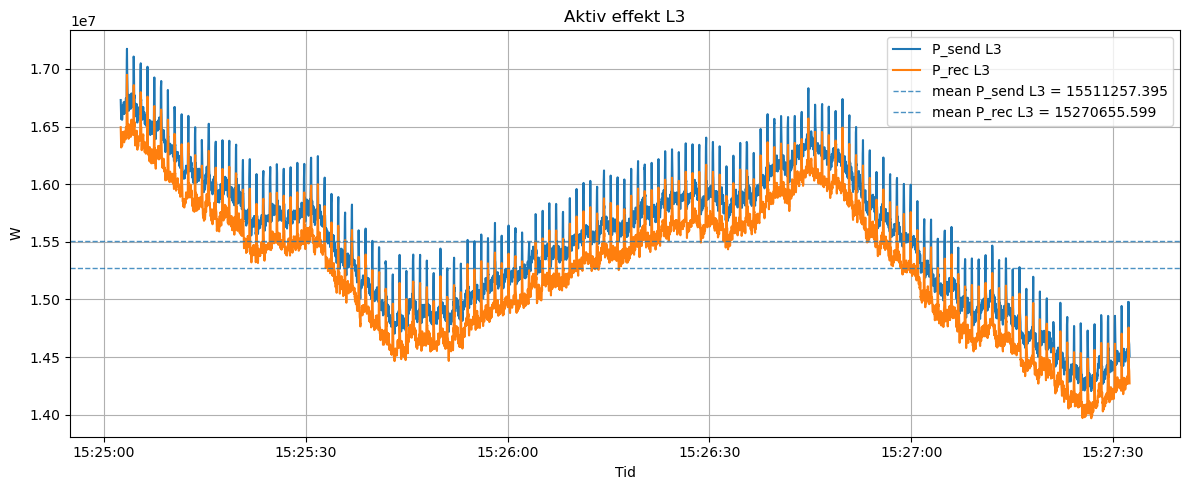

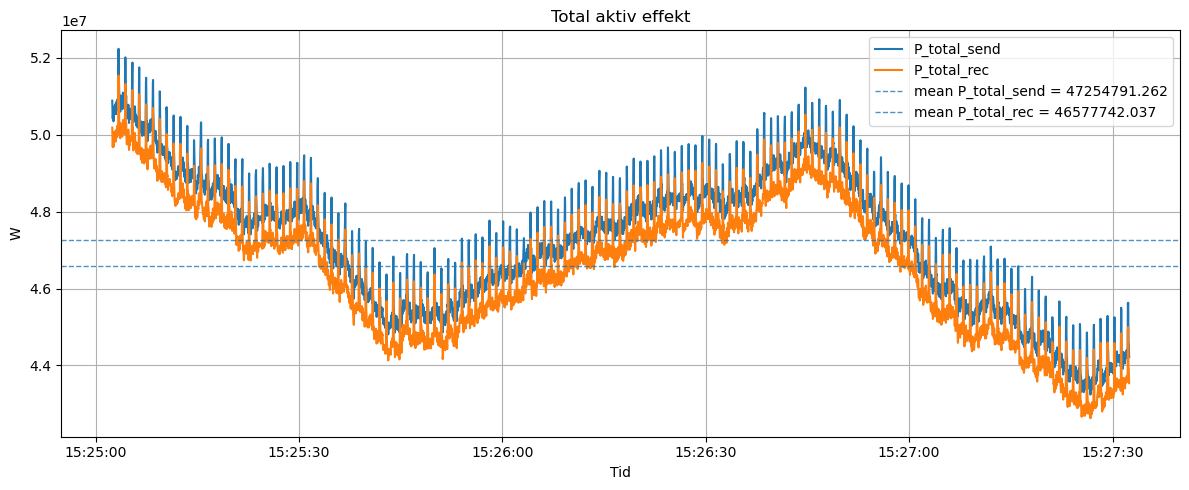

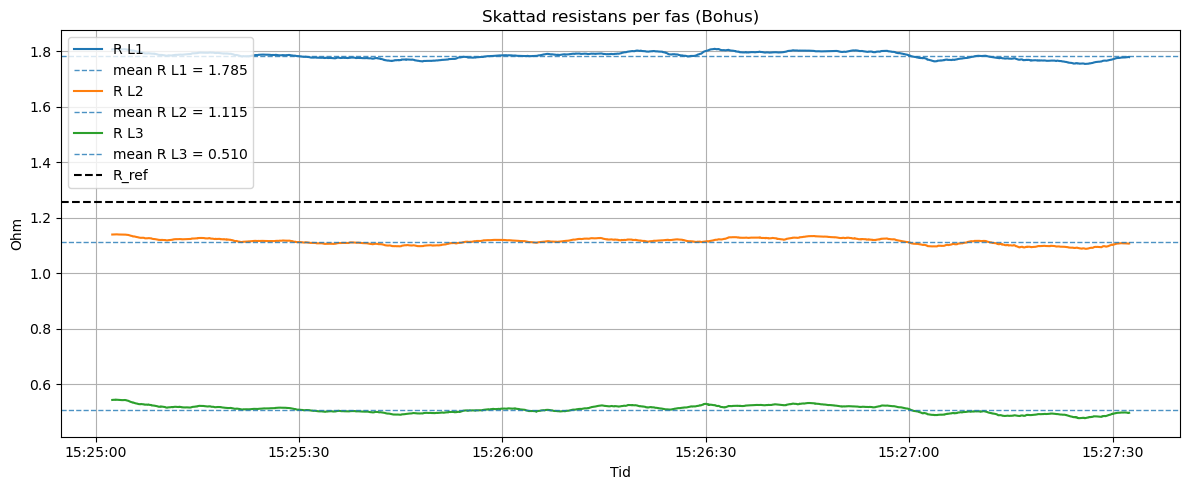

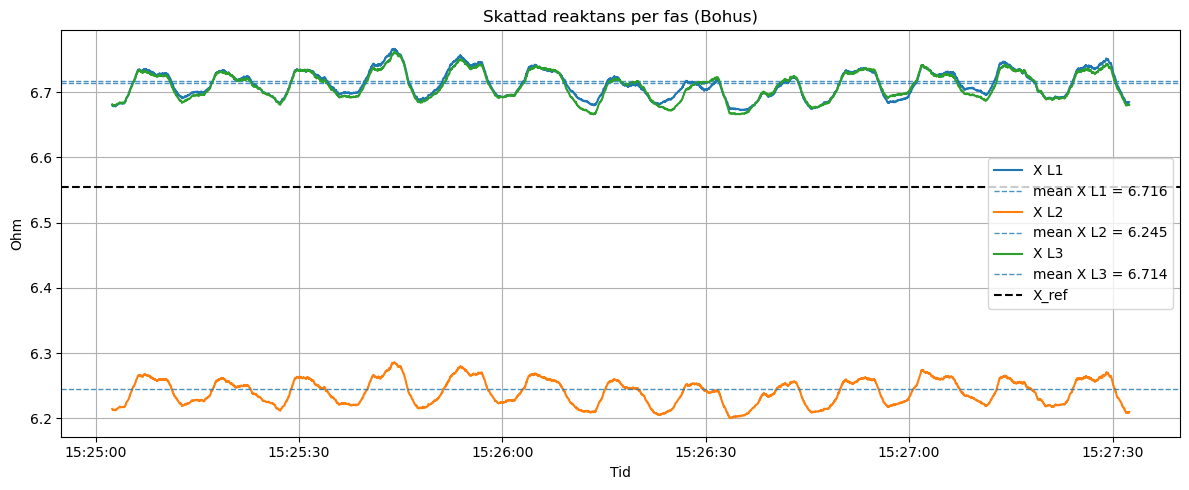

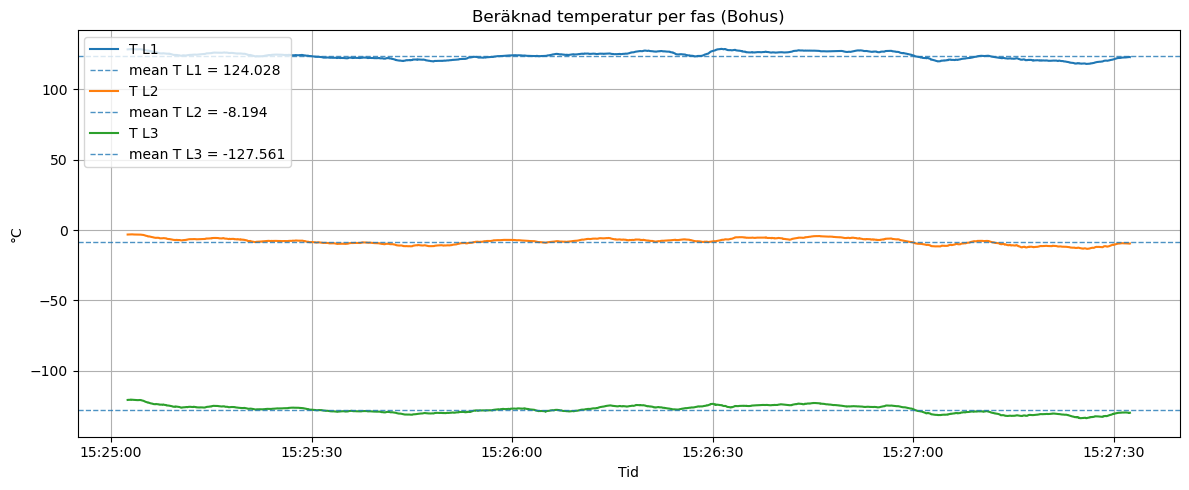

In [2]:
# ============================================================
# BACK TO BASICS + FULL PLOTTING
# send/rec -> synk -> komplexa storheter -> Z-drop -> R -> T
# med cirkulära medelvärden för vinklar
# ============================================================

import os
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", None)
pd.options.mode.chained_assignment = None

# ============================================================
# FILVÄGAR OCH BLADNAMN
# ============================================================

send_file = Path(r"C:\Users\lundi\OneDrive\Skóli\Svíþjóð\Exjobb\Arbetet\Källor\phasor_dlr-main\phasor_dlr-main\data\send-station.xlsx")
rec_file  = Path(r"C:\Users\lundi\OneDrive\Skóli\Svíþjóð\Exjobb\Arbetet\Källor\phasor_dlr-main\phasor_dlr-main\data\rec-station.xlsx")

keyS_sheet  = "K-nyckel"
dataS_sheet = "Station_K_3x15000"

keyR_sheet  = "F-nyckel"
dataR_sheet = "Station_F_3x15000"

print("send finns:", send_file.exists())
print("rec finns :", rec_file.exists())

# ============================================================
# MODELLVAL
# ============================================================

MODEL = "Bohus"   # byt till "Gota" om du vill

MODELS = {
    "Bohus": {
        "length_km": 17.25,
        "RAC_ohm_per_km": 0.0729,
        "alpha": 0.00403,
        "T_ref_C": 20.0,
        "X_ohm_per_km": 0.38,
    },
    "Gota": {
        "length_km": 21.95,
        "RAC_ohm_per_km": 0.0348,
        "alpha": 0.00403,
        "T_ref_C": 20.0,
        "X_ohm_per_km": 0.38,
    },
}

model = MODELS[MODEL]
R_ref = model["RAC_ohm_per_km"] * model["length_km"]
X_ref = model["X_ohm_per_km"] * model["length_km"]
alpha = model["alpha"]
T_ref = model["T_ref_C"]

print(f"\nVald modell: {MODEL}")
print(f"R_ref = {R_ref:.6f} Ω")
print(f"X_ref = {X_ref:.6f} Ω")
print(f"alpha = {alpha:.5f} 1/K")
print(f"T_ref = {T_ref:.1f} °C")

# ============================================================
# PARAMETRAR
# ============================================================

invert_receiver_current = True
smooth_seconds = 2.0
min_current_A = 50.0

# ============================================================
# HJÄLPFUNKTIONER
# ============================================================

def wrap_angle_deg(angle_deg):
    return (angle_deg + 180.0) % 360.0 - 180.0

def circular_mean_deg(angle_deg):
    """Cirkulärt medelvärde i grader."""
    angle_deg = np.asarray(angle_deg, dtype=float)
    angle_deg = angle_deg[~np.isnan(angle_deg)]
    if len(angle_deg) == 0:
        return np.nan
    angle_rad = np.deg2rad(angle_deg)
    return np.rad2deg(np.angle(np.mean(np.exp(1j * angle_rad))))

def read_key_table_safe(filename, sheetname):
    T = pd.read_excel(filename, sheet_name=sheetname, header=None)
    T = T.iloc[:, :2].copy()
    T.columns = ["Parameter", "ID"]
    T = T.dropna(how="all")
    T["Parameter"] = T["Parameter"].astype(str).str.strip()
    T["ID"] = T["ID"].astype(str).str.strip()
    return T

def read_data_table_safe(filename, sheetname):
    D = pd.read_excel(filename, sheet_name=sheetname, header=None)
    D = D.iloc[:, :3].copy()
    D.columns = ["Timestamp", "ID", "Value"]
    D["Timestamp"] = pd.to_datetime(D["Timestamp"], errors="coerce")
    D["ID"] = D["ID"].astype(str).str.strip()
    D["Value"] = (
        D["Value"]
        .astype(str)
        .str.strip()
        .str.replace(",", ".", regex=False)
    )
    D["Value"] = pd.to_numeric(D["Value"], errors="coerce")
    D = D.dropna(subset=["Timestamp"])
    return D

def complex_from_mag_ang(mag, ang_deg):
    return mag * np.exp(1j * np.deg2rad(ang_deg))

def rolling_complex_mean(z, window):
    z_re = pd.Series(np.real(z), index=z.index).rolling(window=window, center=True, min_periods=1).mean()
    z_im = pd.Series(np.imag(z), index=z.index).rolling(window=window, center=True, min_periods=1).mean()
    return z_re + 1j * z_im

def add_mean_line(ax, y, color=None, label_prefix="mean", circular=False):
    if circular:
        mean_val = circular_mean_deg(y)
    else:
        mean_val = np.nanmean(y)
    ax.axhline(mean_val, linestyle="--", linewidth=1.0, color=color, alpha=0.8,
               label=f"{label_prefix} = {mean_val:.3f}")
    return mean_val

# ============================================================
# 1. LÄS IN DATA
# ============================================================

keyS = read_key_table_safe(send_file, keyS_sheet)
keyR = read_key_table_safe(rec_file, keyR_sheet)

send = read_data_table_safe(send_file, dataS_sheet)
rec  = read_data_table_safe(rec_file, dataR_sheet)

print("\nRådata:")
print("send rows:", len(send), "rec rows:", len(rec))
print("unika send timestamps:", send["Timestamp"].nunique())
print("unika rec timestamps :", rec["Timestamp"].nunique())

# ============================================================
# 2. MAPPA ID -> PARAMETER
# ============================================================

send = send.merge(keyS, on="ID", how="inner")
rec  = rec.merge(keyR, on="ID", how="inner")

print("\nEfter mappning:")
print("send rows:", len(send), "rec rows:", len(rec))
print("unika parametrar send:", send["Parameter"].nunique())
print("unika parametrar rec :", rec["Parameter"].nunique())

# ============================================================
# 3. PIVOTERA TILL BRETT FORMAT MED EXAKTA TIMESTAMPS
# ============================================================

wideS = send.pivot_table(index="Timestamp", columns="Parameter", values="Value", aggfunc="first")
wideR = rec.pivot_table(index="Timestamp", columns="Parameter", values="Value", aggfunc="first")

wideS = wideS.add_suffix("_S").sort_index()
wideR = wideR.add_suffix("_R").sort_index()

df_joined = wideS.join(wideR, how="inner").copy()

print("\nExakt join:")
print("joined rows:", len(df_joined))
print("start:", df_joined.index.min())
print("slut :", df_joined.index.max())

required_cols = []
for ph in ["L1", "L2", "L3"]:
    required_cols += [
        f"U{ph}MAG_S", f"U{ph}ANG_S", f"U{ph}MAG_R", f"U{ph}ANG_R",
        f"I{ph}MAG_S", f"I{ph}ANG_S", f"I{ph}MAG_R", f"I{ph}ANG_R",
    ]

missing = [c for c in required_cols if c not in df_joined.columns]
if missing:
    raise ValueError(f"Saknade kolumner: {missing}")

df_joined = df_joined.dropna(subset=required_cols).copy()

# filtrera bort orimliga vinkelvärden
angle_cols = [c for c in df_joined.columns if "ANG" in c]
for c in angle_cols:
    df_joined = df_joined[(df_joined[c] >= -180) & (df_joined[c] <= 180)]

print("rows after filtering angles and dropna:", len(df_joined))

# ============================================================
# 4. SAMPLINGSFREKVENS
# ============================================================

dt = df_joined.index.to_series().diff().dropna().dt.total_seconds()
fs = 1.0 / dt.median()
smooth_window = int(round(smooth_seconds * fs))

print("\nSampling:")
print("fs =", fs, "Hz")
print("smooth_window =", smooth_window, "samples")

# ============================================================
# 5. BERÄKNINGAR
# ============================================================

out = pd.DataFrame(index=df_joined.index)
summary_rows = []

for ph in ["L1", "L2", "L3"]:
    # magnituder och vinklar
    U_mag_S = df_joined[f"U{ph}MAG_S"]
    U_ang_S = df_joined[f"U{ph}ANG_S"]
    U_mag_R = df_joined[f"U{ph}MAG_R"]
    U_ang_R = df_joined[f"U{ph}ANG_R"]

    I_mag_S = df_joined[f"I{ph}MAG_S"]
    I_ang_S = df_joined[f"I{ph}ANG_S"]
    I_mag_R = df_joined[f"I{ph}MAG_R"]
    I_ang_R = df_joined[f"I{ph}ANG_R"]

    # spara råvärden
    out[f"U_mag_S_{ph}"] = U_mag_S
    out[f"U_mag_R_{ph}"] = U_mag_R
    out[f"I_mag_S_{ph}"] = I_mag_S
    out[f"I_mag_R_{ph}"] = I_mag_R

    out[f"U_ang_S_{ph}"] = U_ang_S
    out[f"U_ang_R_{ph}"] = U_ang_R
    out[f"I_ang_S_{ph}"] = I_ang_S
    out[f"I_ang_R_{ph}"] = I_ang_R

    # korrigerad mottagarvinkel
    I_ang_R_corr = wrap_angle_deg(I_ang_R + (180.0 if invert_receiver_current else 0.0))
    out[f"I_ang_R_corr_{ph}"] = I_ang_R_corr

    # komplexa storheter
    Vs = complex_from_mag_ang(U_mag_S, U_ang_S)
    Vr = complex_from_mag_ang(U_mag_R, U_ang_R)

    Is = complex_from_mag_ang(I_mag_S, I_ang_S)
    Ir = complex_from_mag_ang(I_mag_R, I_ang_R)

    if invert_receiver_current:
        Ir = -Ir

    # aktiv effekt
    P_send = np.real(Vs * np.conj(Is))
    P_rec  = np.real(Vr * np.conj(Ir))

    # spänningsfall och medelström
    dV = Vs - Vr
    I_avg = 0.5 * (Is + Ir)

    dV_smooth = rolling_complex_mean(pd.Series(dV, index=df_joined.index), smooth_window)
    I_avg_smooth = rolling_complex_mean(pd.Series(I_avg, index=df_joined.index), smooth_window)

    I_avg_abs = np.abs(I_avg_smooth)
    valid = I_avg_abs > min_current_A

    Z_est = pd.Series(np.nan + 1j*np.nan, index=df_joined.index, dtype=complex)
    Z_est.loc[valid] = dV_smooth.loc[valid] / I_avg_smooth.loc[valid]

    R_est = np.real(Z_est)
    X_est = np.imag(Z_est)
    T_est = ((R_est / R_ref) - 1.0) / alpha + T_ref

    # vinkelskillnader
    dU_deg = wrap_angle_deg(U_ang_S - U_ang_R)
    dI_deg = wrap_angle_deg(I_ang_S - I_ang_R_corr)

    out[f"P_send_{ph}"] = P_send
    out[f"P_rec_{ph}"] = P_rec
    out[f"R_{ph}"] = R_est
    out[f"X_{ph}"] = X_est
    out[f"T_{ph}"] = T_est
    out[f"ΔU_deg_{ph}"] = dU_deg
    out[f"ΔI_deg_{ph}"] = dI_deg

    summary_rows.append({
        "Phase": ph,
        "Model": MODEL,
        "R_ref_Ohm": R_ref,
        "X_ref_Ohm": X_ref,
        "U_mag_S_mean": np.nanmean(U_mag_S),
        "U_mag_R_mean": np.nanmean(U_mag_R),
        "I_mag_S_mean": np.nanmean(I_mag_S),
        "I_mag_R_mean": np.nanmean(I_mag_R),
        "U_ang_S_mean": circular_mean_deg(U_ang_S),
        "U_ang_R_mean": circular_mean_deg(U_ang_R),
        "I_ang_S_mean": circular_mean_deg(I_ang_S),
        "I_ang_R_mean": circular_mean_deg(I_ang_R),
        "I_ang_R_corr_mean": circular_mean_deg(I_ang_R_corr),
        "dU_mean_deg": circular_mean_deg(dU_deg),
        "dI_mean_deg": circular_mean_deg(dI_deg),
        "P_send_mean_W": np.nanmean(P_send),
        "P_rec_mean_W": np.nanmean(P_rec),
        "R_mean_Ohm": np.nanmean(R_est),
        "R_std_Ohm": np.nanstd(R_est),
        "X_mean_Ohm": np.nanmean(X_est),
        "X_std_Ohm": np.nanstd(X_est),
        "T_mean_C": np.nanmean(T_est),
        "T_std_C": np.nanstd(T_est),
    })

summary_df = pd.DataFrame(summary_rows)

out["P_total_send"] = out[[f"P_send_{ph}" for ph in ["L1", "L2", "L3"]]].sum(axis=1)
out["P_total_rec"]  = out[[f"P_rec_{ph}" for ph in ["L1", "L2", "L3"]]].sum(axis=1)

print("\n=== Summary ===")
display(summary_df)

# ============================================================
# 6. SPARA RESULTAT
# ============================================================

VERSION = "bohus_v02.2_delta_U"   # <-- ändra bara denna rad nästa gång

output_dir = send_file.parent / VERSION
output_dir.mkdir(parents=True, exist_ok=True)


df_joined.reset_index().to_excel(output_dir / "df_joined_Zdrop.xlsx", index=False)
out.reset_index().to_excel(output_dir / "results_Zdrop.xlsx", index=False)
summary_df.to_excel(output_dir / "summary_Zdrop.xlsx", index=False)
summary_df.to_csv(output_dir / "summary_Zdrop.csv", index=False)

print("\nSparat till:", output_dir)

# ============================================================
# 7. PLOTTAR: SPÄNNINGSVINKLAR
# ============================================================

for ph in ["L1", "L2", "L3"]:
    fig, ax = plt.subplots(figsize=(12, 5))
    ax.plot(out.index, out[f"U_ang_S_{ph}"], label=f"U angle send {ph}")
    ax.plot(out.index, out[f"U_ang_R_{ph}"], label=f"U angle rec {ph}")
    add_mean_line(ax, out[f"U_ang_S_{ph}"], label_prefix=f"mean U_send {ph}", circular=True)
    add_mean_line(ax, out[f"U_ang_R_{ph}"], label_prefix=f"mean U_rec {ph}", circular=True)
    ax.set_title(f"Spänningsvinklar {ph}")
    ax.set_ylabel("grader")
    ax.set_xlabel("Tid")
    ax.grid(True)
    ax.legend()
    fig.tight_layout()
    fig.savefig(output_dir / f"plot_U_angles_{ph}.png", dpi=200)
    plt.show()

# ============================================================
# 8. PLOTTAR: STRÖMVINKLAR
# ============================================================

for ph in ["L1", "L2", "L3"]:
    fig, ax = plt.subplots(figsize=(12, 5))
    ax.plot(out.index, out[f"I_ang_S_{ph}"], label=f"I angle send {ph}")
    ax.plot(out.index, out[f"I_ang_R_{ph}"], label=f"I angle rec raw {ph}")
    ax.plot(out.index, out[f"I_ang_R_corr_{ph}"], label=f"I angle rec corr {ph}")
    add_mean_line(ax, out[f"I_ang_S_{ph}"], label_prefix=f"mean I_send {ph}", circular=True)
    add_mean_line(ax, out[f"I_ang_R_{ph}"], label_prefix=f"mean I_rec raw {ph}", circular=True)
    add_mean_line(ax, out[f"I_ang_R_corr_{ph}"], label_prefix=f"mean I_rec corr {ph}", circular=True)
    ax.set_title(f"Strömvinklar {ph}")
    ax.set_ylabel("grader")
    ax.set_xlabel("Tid")
    ax.grid(True)
    ax.legend()
    fig.tight_layout()
    fig.savefig(output_dir / f"plot_I_angles_{ph}.png", dpi=200)
    plt.show()

# ============================================================
# 9. PLOTTAR: VINKELSKILLNADER
# ============================================================

fig, axs = plt.subplots(3, 1, figsize=(12, 8), sharex=True)
for i, ph in enumerate(["L1", "L2", "L3"]):
    axs[i].plot(out.index, out[f"ΔU_deg_{ph}"], label=f"ΔU {ph}")
    axs[i].plot(out.index, out[f"ΔI_deg_{ph}"], label=f"ΔI {ph}")
    add_mean_line(axs[i], out[f"ΔU_deg_{ph}"], label_prefix=f"mean ΔU {ph}", circular=True)
    add_mean_line(axs[i], out[f"ΔI_deg_{ph}"], label_prefix=f"mean ΔI {ph}", circular=True)
    axs[i].axhline(0, color="gray", linestyle="--", linewidth=0.8)
    axs[i].grid(True)
    axs[i].legend()
    axs[i].set_ylabel("grader")
axs[-1].set_xlabel("Tid")
fig.suptitle(f"Vinkelskillnader ({MODEL})")
fig.tight_layout()
fig.savefig(output_dir / "01_vinkelskillnader.png", dpi=200)
plt.show()

# ============================================================
# 10. PLOTTAR: SPÄNNINGSMAGNITUDER
# ============================================================

for ph in ["L1", "L2", "L3"]:
    fig, ax = plt.subplots(figsize=(12, 5))
    ax.plot(out.index, out[f"U_mag_S_{ph}"], label=f"U_send {ph}")
    ax.plot(out.index, out[f"U_mag_R_{ph}"], label=f"U_rec {ph}")
    add_mean_line(ax, out[f"U_mag_S_{ph}"], label_prefix=f"mean U_send {ph}")
    add_mean_line(ax, out[f"U_mag_R_{ph}"], label_prefix=f"mean U_rec {ph}")
    ax.set_title(f"Spänningsmagnituder {ph}")
    ax.set_ylabel("V")
    ax.set_xlabel("Tid")
    ax.grid(True)
    ax.legend()
    fig.tight_layout()
    fig.savefig(output_dir / f"plot_U_magnitude_{ph}.png", dpi=200)
    plt.show()

# ============================================================
# 11. PLOTTAR: STRÖMMAGNITUDER
# ============================================================

for ph in ["L1", "L2", "L3"]:
    fig, ax = plt.subplots(figsize=(12, 5))
    ax.plot(out.index, out[f"I_mag_S_{ph}"], label=f"I_send {ph}")
    ax.plot(out.index, out[f"I_mag_R_{ph}"], label=f"I_rec {ph}")
    add_mean_line(ax, out[f"I_mag_S_{ph}"], label_prefix=f"mean I_send {ph}")
    add_mean_line(ax, out[f"I_mag_R_{ph}"], label_prefix=f"mean I_rec {ph}")
    ax.set_title(f"Strömmagnituder {ph}")
    ax.set_ylabel("A")
    ax.set_xlabel("Tid")
    ax.grid(True)
    ax.legend()
    fig.tight_layout()
    fig.savefig(output_dir / f"plot_I_magnitude_{ph}.png", dpi=200)
    plt.show()

# ============================================================
# 12. PLOTTAR: EFFEKT
# ============================================================

for ph in ["L1", "L2", "L3"]:
    fig, ax = plt.subplots(figsize=(12, 5))
    ax.plot(out.index, out[f"P_send_{ph}"], label=f"P_send {ph}")
    ax.plot(out.index, out[f"P_rec_{ph}"], label=f"P_rec {ph}")
    add_mean_line(ax, out[f"P_send_{ph}"], label_prefix=f"mean P_send {ph}")
    add_mean_line(ax, out[f"P_rec_{ph}"], label_prefix=f"mean P_rec {ph}")
    ax.set_title(f"Aktiv effekt {ph}")
    ax.set_ylabel("W")
    ax.set_xlabel("Tid")
    ax.grid(True)
    ax.legend()
    fig.tight_layout()
    fig.savefig(output_dir / f"plot_power_{ph}.png", dpi=200)
    plt.show()

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(out.index, out["P_total_send"], label="P_total_send")
ax.plot(out.index, out["P_total_rec"], label="P_total_rec")
add_mean_line(ax, out["P_total_send"], label_prefix="mean P_total_send")
add_mean_line(ax, out["P_total_rec"], label_prefix="mean P_total_rec")
ax.set_title("Total aktiv effekt")
ax.set_ylabel("W")
ax.set_xlabel("Tid")
ax.grid(True)
ax.legend()
fig.tight_layout()
fig.savefig(output_dir / "plot_power_total.png", dpi=200)
plt.show()

# ============================================================
# 13. PLOTTAR: RESISTANS, REAKTANS, TEMPERATUR
# ============================================================

fig, ax = plt.subplots(figsize=(12, 5))
for ph in ["L1", "L2", "L3"]:
    ax.plot(out.index, out[f"R_{ph}"], label=f"R {ph}")
    add_mean_line(ax, out[f"R_{ph}"], label_prefix=f"mean R {ph}")
ax.axhline(R_ref, color="black", linestyle="--", label="R_ref")
ax.set_title(f"Skattad resistans per fas ({MODEL})")
ax.set_ylabel("Ohm")
ax.set_xlabel("Tid")
ax.grid(True)
ax.legend()
fig.tight_layout()
fig.savefig(output_dir / "03_resistans_Zdrop.png", dpi=200)
plt.show()

fig, ax = plt.subplots(figsize=(12, 5))
for ph in ["L1", "L2", "L3"]:
    ax.plot(out.index, out[f"X_{ph}"], label=f"X {ph}")
    add_mean_line(ax, out[f"X_{ph}"], label_prefix=f"mean X {ph}")
ax.axhline(X_ref, color="black", linestyle="--", label="X_ref")
ax.set_title(f"Skattad reaktans per fas ({MODEL})")
ax.set_ylabel("Ohm")
ax.set_xlabel("Tid")
ax.grid(True)
ax.legend()
fig.tight_layout()
fig.savefig(output_dir / "04_reaktans_Zdrop.png", dpi=200)
plt.show()

fig, ax = plt.subplots(figsize=(12, 5))
for ph in ["L1", "L2", "L3"]:
    ax.plot(out.index, out[f"T_{ph}"], label=f"T {ph}")
    add_mean_line(ax, out[f"T_{ph}"], label_prefix=f"mean T {ph}")
ax.set_title(f"Beräknad temperatur per fas ({MODEL})")
ax.set_ylabel("°C")
ax.set_xlabel("Tid")
ax.grid(True)
ax.legend()
fig.tight_layout()
fig.savefig(output_dir / "05_temperatur_Zdrop.png", dpi=200)
plt.show()